In [1]:
# accesso a google drive
from google.colab import drive

drive.mount('/content/drive/')

Mounted at /content/drive/


Import dataset Routes

In [2]:
# import del database routes
import pandas as pd
df_routes_ori = pd.read_csv("drive/MyDrive/Progetto Data Analytics/routes.csv")
df_routes_ori

,index,Airline,Airline ID,Source airport,Source airport ID,Destination airport,Destination airport ID,Codeshare,Stops,Equipment
0,0,2B,410,AER,2965,KZN,2990,NaN,0,CR2
1,1,2B,410,ASF,2966,KZN,2990,NaN,0,CR2
2,2,2B,410,ASF,2966,MRV,2962,NaN,0,CR2
3,3,2B,410,CEK,2968,KZN,2990,NaN,0,CR2
4,4,2B,410,CEK,2968,OVB,4078,NaN,0,CR2
...,...,...,...,...,...,...,...,...,...,...
67658,67658,ZL,4178,WYA,6334,ADL,3341,NaN,0,SF3
67659,67659,ZM,19016,DME,4029,FRU,2912,NaN,0,734
67660,67660,ZM,19016,FRU,2912,DME,4029,NaN,0,734
67661,67661,ZM,19016,FRU,2912,OSS,2913,NaN,0,734


In [3]:
# Rimuoviamo le righe in cui il valore della colonna 'Stops' è diverso da 0 (ci occupiamo di voli diretti)
df_routes_ori = df_routes_ori.loc[df_routes_ori['Stops'] == 0]
df_routes_ori.head()

,index,Airline,Airline ID,Source airport,Source airport ID,Destination airport,Destination airport ID,Codeshare,Stops,Equipment
0,0,2B,410,AER,2965,KZN,2990,NaN,0,CR2
1,1,2B,410,ASF,2966,KZN,2990,NaN,0,CR2
2,2,2B,410,ASF,2966,MRV,2962,NaN,0,CR2
3,3,2B,410,CEK,2968,KZN,2990,NaN,0,CR2
4,4,2B,410,CEK,2968,OVB,4078,NaN,0,CR2


In [4]:
df_routes = df_routes_ori.loc[:, ['Source airport', 'Source airport ID', 'Destination airport', 'Destination airport ID']]
df_routes.head()

,Source airport,Source airport ID,Destination airport,Destination airport ID
0,AER,2965,KZN,2990
1,ASF,2966,KZN,2990
2,ASF,2966,MRV,2962
3,CEK,2968,KZN,2990
4,CEK,2968,OVB,4078


Import dataset Airports

In [5]:
#import del db airports, per capire dove sono situati i diversi aeroporti

df_airports = pd.read_csv("drive/MyDrive/Progetto Data Analytics/airports.csv")
df_airports

,index,Airport ID,Name,City,Country,IATA,ICAO,Latitude,Longitude,Altitude,Timezone,DST,Tz database time zone,Type,Source
0,0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,5282,10,U,Pacific/Port_Moresby,airport,OurAirports
1,1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,20,10,U,Pacific/Port_Moresby,airport,OurAirports
2,2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,5388,10,U,Pacific/Port_Moresby,airport,OurAirports
3,3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,239,10,U,Pacific/Port_Moresby,airport,OurAirports
4,4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,146,10,U,Pacific/Port_Moresby,airport,OurAirports
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7693,7693,14106,Rogachyovo Air Base,Belaya,Russia,\N,ULDA,71.616699,52.478298,272,\N,\N,\N,airport,OurAirports
7694,7694,14107,Ulan-Ude East Airport,Ulan Ude,Russia,\N,XIUW,51.849998,107.737999,1670,\N,\N,\N,airport,OurAirports
7695,7695,14108,Krechevitsy Air Base,Novgorod,Russia,\N,ULLK,58.625000,31.385000,85,\N,\N,\N,airport,OurAirports
7696,7696,14109,Desierto de Atacama Airport,Copiapo,Chile,CPO,SCAT,-27.261200,-70.779198,670,\N,\N,\N,airport,OurAirports


In [6]:
# Selezioniamo solo i record con paesi desiderati
countries_to_keep = ['France']
df_airports = df_airports[df_airports['Country'].isin(countries_to_keep)]
df_airports

,index,Airport ID,Name,City,Country,IATA,ICAO,Latitude,Longitude,Altitude,Timezone,DST,Tz database time zone,Type,Source
1219,1219,1254,Calais-Dunkerque Airport,Calais,France,CQF,LFAC,50.962101,1.954760,12,1,E,Europe/Paris,airport,OurAirports
1220,1220,1255,Péronne-Saint-Quentin Airport,Peronne,France,\N,LFAG,49.868500,3.029580,295,1,E,Europe/Paris,airport,OurAirports
1221,1221,1256,Nangis-Les Loges Airport,Nangis,France,\N,LFAI,48.596199,3.006790,428,1,E,Europe/Paris,airport,OurAirports
1222,1222,1257,Bagnoles-de-l'Orne-Couterne Airport,Bagnole-de-l'orne,France,\N,LFAO,48.545799,-0.387444,718,1,E,Europe/Paris,airport,OurAirports
1223,1223,1258,Albert-Bray Airport,Albert,France,BYF,LFAQ,49.971500,2.697660,364,1,E,Europe/Paris,airport,OurAirports
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6883,6883,11170,Lure Malbouhans Air Base,Malbouhans,France,\N,LFYL,47.704700,6.545830,1040,1,E,\N,airport,OurAirports
7118,7118,11881,Blois-Le Breuil Airport,Blois/Le Breuil,France,\N,LFOQ,47.678502,1.208840,398,\N,\N,\N,airport,OurAirports
7329,7329,12640,Lognes Emerainville Airport,Lognes,France,\N,LFPL,48.821028,2.625967,359,1,E,\N,airport,OurAirports
7487,7487,13411,St Pierre d'Oléron Airfield,Saint Pierre d'Oleron,France,\N,LFDP,45.959202,-1.316110,20,-1,E,\N,airport,OurAirports


In [7]:
# Selezioniamo solo le colonne desiderate
df_airports = df_airports.loc[:, ['Airport ID', 'Name', 'City', 'Country']]
df_airports.head()

,Airport ID,Name,City,Country
1219,1254,Calais-Dunkerque Airport,Calais,France
1220,1255,Péronne-Saint-Quentin Airport,Peronne,France
1221,1256,Nangis-Les Loges Airport,Nangis,France
1222,1257,Bagnoles-de-l'Orne-Couterne Airport,Bagnole-de-l'orne,France
1223,1258,Albert-Bray Airport,Albert,France


In [8]:
# Eliminiamo i record con 'Source Airport ID' uguale a '\N'
df_routes = df_routes[df_routes['Source airport ID'] != '\\N']

# Eliminiamo i record con 'Destination Airport ID' uguale a '\N'
df_routes = df_routes[df_routes['Destination airport ID'] != '\\N']

# Trasformiamo la colonna 'Source Airport ID' in tipo int64
df_routes['Source airport ID'] = df_routes['Source airport ID'].astype('int64')

# Trasformiamo la colonna 'Destination Airport ID' in tipo int64
df_routes['Destination airport ID'] = df_routes['Destination airport ID'].astype('int64')

<ipython-input-8-60ec1f102d6a>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_routes['Source airport ID'] = df_routes['Source airport ID'].astype('int64')
<ipython-input-8-60ec1f102d6a>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_routes['Destination airport ID'] = df_routes['Destination airport ID'].astype('int64')


Creazione di un unico dataset

In [9]:
# Eseguiamo l'inner join sugli aeroporti di partenza
df_merged = pd.merge(df_routes, df_airports, left_on='Source airport ID', right_on='Airport ID', how='inner')
df_merged

,Source airport,Source airport ID,Destination airport,Destination airport ID,Airport ID,Name,City,Country
0,BOD,1264,ZRH,1678,1264,Bordeaux-Mérignac Airport,Bordeaux,France
1,BOD,1264,HER,1452,1264,Bordeaux-Mérignac Airport,Bordeaux,France
2,BOD,1264,FCO,1555,1264,Bordeaux-Mérignac Airport,Bordeaux,France
3,BOD,1264,LIL,1399,1264,Bordeaux-Mérignac Airport,Bordeaux,France
4,BOD,1264,LYS,1335,1264,Bordeaux-Mérignac Airport,Bordeaux,France
...,...,...,...,...,...,...,...,...
1921,DIJ,1425,TLS,1273,1425,Dijon-Bourgogne Airport,Dijon,France
1922,LEH,1371,LYS,1335,1371,Le Havre Octeville Airport,Le Havre,France
1923,PGX,1279,EGC,1265,1279,Périgueux-Bassillac Airport,Perigueux,France
1924,PGX,1279,ORY,1386,1279,Périgueux-Bassillac Airport,Perigueux,France


In [10]:
# Rimuoviamo la colonna 'Airport ID' da df_merged, in quanto ripetizione di source airport id
df_merged = df_merged.drop(columns=['Airport ID'])

# Rinominiamo le colonne, in vista della seconda merge
df_merged = df_merged.rename(columns={
    'Name': 'Source airport name',
    'City': 'Source airport city',
    'Country': 'Source airport country'
})

df_merged.head()

,Source airport,Source airport ID,Destination airport,Destination airport ID,Source airport name,Source airport city,Source airport country
0,BOD,1264,ZRH,1678,Bordeaux-Mérignac Airport,Bordeaux,France
1,BOD,1264,HER,1452,Bordeaux-Mérignac Airport,Bordeaux,France
2,BOD,1264,FCO,1555,Bordeaux-Mérignac Airport,Bordeaux,France
3,BOD,1264,LIL,1399,Bordeaux-Mérignac Airport,Bordeaux,France
4,BOD,1264,LYS,1335,Bordeaux-Mérignac Airport,Bordeaux,France


In [11]:
# Eseguiamo l'inner join sugli aeroporti di destinazione
df_merged = pd.merge(df_merged, df_airports, left_on='Destination airport ID', right_on='Airport ID', how='inner')
df_merged

,Source airport,Source airport ID,Destination airport,Destination airport ID,Source airport name,Source airport city,Source airport country,Airport ID,Name,City,Country
0,BOD,1264,LIL,1399,Bordeaux-Mérignac Airport,Bordeaux,France,1399,Lille-Lesquin Airport,Lille,France
1,BOD,1264,LIL,1399,Bordeaux-Mérignac Airport,Bordeaux,France,1399,Lille-Lesquin Airport,Lille,France
2,LYS,1335,LIL,1399,Lyon Saint-Exupéry Airport,Lyon,France,1399,Lille-Lesquin Airport,Lille,France
3,MPL,1359,LIL,1399,Montpellier-Méditerranée Airport,Montpellier,France,1399,Lille-Lesquin Airport,Lille,France
4,TLS,1273,LIL,1399,Toulouse-Blagnac Airport,Toulouse,France,1399,Lille-Lesquin Airport,Lille,France
...,...,...,...,...,...,...,...,...,...,...,...
478,ORY,1386,PGX,1279,Paris-Orly Airport,Paris,France,1279,Périgueux-Bassillac Airport,Perigueux,France
479,EGC,1265,PGX,1279,Bergerac-Roumanière Airport,Bergerac,France,1279,Périgueux-Bassillac Airport,Perigueux,France
480,ORY,1386,LPY,1313,Paris-Orly Airport,Paris,France,1313,Le Puy-Loudes Airport,Le Puy,France
481,BZR,1360,BVA,1367,Béziers-Vias Airport,Beziers,France,1367,Paris Beauvais Tillé Airport,Beauvais,France


In [12]:
# Rimuoviamo la colonna 'Airport ID' da df_merged, in quanto ripetizione di source airport id
df_merged = df_merged.drop(columns=['Airport ID'])

# Rinominiamo le colonne
df_merged = df_merged.rename(columns={
    'Name': 'Destination airport name',
    'City': 'Destination airport city',
    'Country': 'Destination airport country'
})

df_merged

,Source airport,Source airport ID,Destination airport,Destination airport ID,Source airport name,Source airport city,Source airport country,Destination airport name,Destination airport city,Destination airport country
0,BOD,1264,LIL,1399,Bordeaux-Mérignac Airport,Bordeaux,France,Lille-Lesquin Airport,Lille,France
1,BOD,1264,LIL,1399,Bordeaux-Mérignac Airport,Bordeaux,France,Lille-Lesquin Airport,Lille,France
2,LYS,1335,LIL,1399,Lyon Saint-Exupéry Airport,Lyon,France,Lille-Lesquin Airport,Lille,France
3,MPL,1359,LIL,1399,Montpellier-Méditerranée Airport,Montpellier,France,Lille-Lesquin Airport,Lille,France
4,TLS,1273,LIL,1399,Toulouse-Blagnac Airport,Toulouse,France,Lille-Lesquin Airport,Lille,France
...,...,...,...,...,...,...,...,...,...,...
478,ORY,1386,PGX,1279,Paris-Orly Airport,Paris,France,Périgueux-Bassillac Airport,Perigueux,France
479,EGC,1265,PGX,1279,Bergerac-Roumanière Airport,Bergerac,France,Périgueux-Bassillac Airport,Perigueux,France
480,ORY,1386,LPY,1313,Paris-Orly Airport,Paris,France,Le Puy-Loudes Airport,Le Puy,France
481,BZR,1360,BVA,1367,Béziers-Vias Airport,Beziers,France,Paris Beauvais Tillé Airport,Beauvais,France


In [13]:
# Contiamo il numero di duplicati per ciascuna riga
df_merged['weight'] = df_merged.duplicated(keep=False)

# Calcoliamo il numero totale di duplicati per ciascuna riga
df_merged['weight'] = df_merged.groupby(df_merged.columns.tolist())['weight'].transform('sum')

# Rimuoviamo i duplicati tenendo solo la prima occorrenza
df_merged = df_merged.drop_duplicates()

# Aumentiamo il valore della colonna 'weight' di 1 (archi tot = numero repliche + 1)
df_merged['weight'] += 1

# Resettiamo gli indici del DataFrame risultante
df_merged.reset_index(drop=True, inplace=True)

df_merged

<ipython-input-13-d1920a428c66>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['weight'] += 1


,Source airport,Source airport ID,Destination airport,Destination airport ID,Source airport name,Source airport city,Source airport country,Destination airport name,Destination airport city,Destination airport country,weight
0,BOD,1264,LIL,1399,Bordeaux-Mérignac Airport,Bordeaux,France,Lille-Lesquin Airport,Lille,France,3
1,LYS,1335,LIL,1399,Lyon Saint-Exupéry Airport,Lyon,France,Lille-Lesquin Airport,Lille,France,1
2,MPL,1359,LIL,1399,Montpellier-Méditerranée Airport,Montpellier,France,Lille-Lesquin Airport,Lille,France,1
3,TLS,1273,LIL,1399,Toulouse-Blagnac Airport,Toulouse,France,Lille-Lesquin Airport,Lille,France,3
4,BIA,1321,LIL,1399,Bastia-Poretta Airport,Bastia,France,Lille-Lesquin Airport,Lille,France,3
...,...,...,...,...,...,...,...,...,...,...,...
307,ORY,1386,PGX,1279,Paris-Orly Airport,Paris,France,Périgueux-Bassillac Airport,Perigueux,France,1
308,EGC,1265,PGX,1279,Bergerac-Roumanière Airport,Bergerac,France,Périgueux-Bassillac Airport,Perigueux,France,1
309,ORY,1386,LPY,1313,Paris-Orly Airport,Paris,France,Le Puy-Loudes Airport,Le Puy,France,1
310,BZR,1360,BVA,1367,Béziers-Vias Airport,Beziers,France,Paris Beauvais Tillé Airport,Beauvais,France,1


Creazione **Grafo**

In [14]:
!sudo apt install build-essential python-dev libxml2 libxml2-dev zlib1g-dev #in prompt
!sudo pip install cairocffi
!pip install python-igraph


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Package python-dev is not available, but is referred to by another package.
This may mean that the package is missing, has been obsoleted, or
is only available from another source
However the following packages replace it:
  python2-dev python2 python-dev-is-python3

E: Package 'python-dev' has no installation candidate
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 26.7 MB/s eta 0:00:00


In [15]:
import igraph as ig
# Crea un grafo con TupleList, indicando quali colonne rappresentano gli estremi degli archi
g = ig.Graph.TupleList(df_merged[['Source airport name', 'Destination airport name']].itertuples(index=False), directed=True)

# Aggiungiamo attributi agli archi
for _, row in df_merged.iterrows():
    # Nodi di partenza e destinazione
    source_id = row['Source airport name']
    dest_id = row['Destination airport name']

    # Trova l'ID dell'arco
    edge = g.get_eid(source_id, dest_id)

    # Assegna il peso dell'arco
    g.es[edge]['weight'] = row['weight']

# Assicurati che il grafo sia creato correttamente
print("Nodi del grafo:", g.vs['name'])  # Mostra i nodi del grafo
print("Archi del grafo:", g.es)  # Mostra gli archi del grafo


Nodi del grafo: ['Bordeaux-Mérignac Airport', 'Lille-Lesquin Airport', 'Lyon Saint-Exupéry Airport', 'Montpellier-Méditerranée Airport', 'Toulouse-Blagnac Airport', 'Bastia-Poretta Airport', "Nice-Côte d'Azur Airport", 'Marseille Provence Airport', 'Nantes Atlantique Airport', 'Ajaccio-Napoléon Bonaparte Airport', 'Biarritz-Anglet-Bayonne Airport', 'Figari Sud-Corse Airport', 'Strasbourg Airport', 'Charles de Gaulle International Airport', 'Brest Bretagne Airport', 'Clermont-Ferrand Auvergne Airport', 'Caen-Carpiquet Airport', 'Metz-Nancy-Lorraine Airport', 'Lorient South Brittany (Bretagne Sud) Airport', 'Paris-Orly Airport', 'Poitiers-Biard Airport', 'Pau Pyrénées Airport', 'Rennes-Saint-Jacques Airport', 'Limoges Airport', 'Le Havre Octeville Airport', 'EuroAirport Basel-Mulhouse-Freiburg Airport', 'Calvi-Sainte-Catherine Airport', 'Perpignan-Rivesaltes (Llabanère) Airport', 'Tours-Val-de-Loire Airport', 'Agen-La Garenne Airport', 'Aurillac Airport', 'Brive Souillac Airport', 'Castr

In [16]:
g.vs.attribute_names()

['name']

In [17]:
g.vs.get_attribute_values('name')

['Bordeaux-Mérignac Airport',
 'Lille-Lesquin Airport',
 'Lyon Saint-Exupéry Airport',
 'Montpellier-Méditerranée Airport',
 'Toulouse-Blagnac Airport',
 'Bastia-Poretta Airport',
 "Nice-Côte d'Azur Airport",
 'Marseille Provence Airport',
 'Nantes Atlantique Airport',
 'Ajaccio-Napoléon Bonaparte Airport',
 'Biarritz-Anglet-Bayonne Airport',
 'Figari Sud-Corse Airport',
 'Strasbourg Airport',
 'Charles de Gaulle International Airport',
 'Brest Bretagne Airport',
 'Clermont-Ferrand Auvergne Airport',
 'Caen-Carpiquet Airport',
 'Metz-Nancy-Lorraine Airport',
 'Lorient South Brittany (Bretagne Sud) Airport',
 'Paris-Orly Airport',
 'Poitiers-Biard Airport',
 'Pau Pyrénées Airport',
 'Rennes-Saint-Jacques Airport',
 'Limoges Airport',
 'Le Havre Octeville Airport',
 'EuroAirport Basel-Mulhouse-Freiburg Airport',
 'Calvi-Sainte-Catherine Airport',
 'Perpignan-Rivesaltes (Llabanère) Airport',
 'Tours-Val-de-Loire Airport',
 'Agen-La Garenne Airport',
 'Aurillac Airport',
 'Brive Souillac A

In [18]:
from collections import Counter

# Ottengo l'elenco degli archi
edge_list = g.get_edgelist()

# Conto quante volte ciascun arco appare nella lista
edge_counts = Counter(edge_list)

# Stampo gli archi duplicati
for edge, count in edge_counts.items():
    if count > 1:
        print(f"Arco {edge} duplicato {count} volte.")

# Conto il numero di archi nel grafo
num_edges = g.ecount()
print("Numero di archi nel grafo:", num_edges)


Numero di archi nel grafo: 312


In [19]:
#ig.plot(g)

In [20]:
print(df_merged['weight'].describe())

count    312.000000
mean       1.929487
std        1.315806
min        1.000000
25%        1.000000
50%        1.000000
75%        3.000000
max        9.000000
Name: weight, dtype: float64


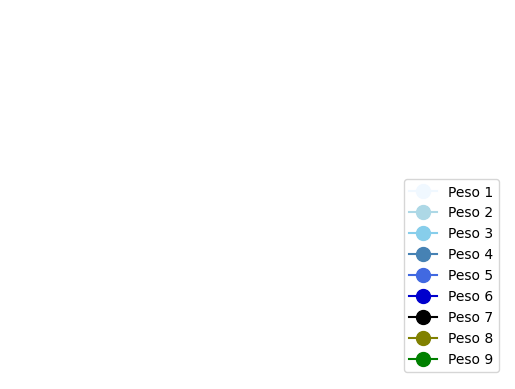

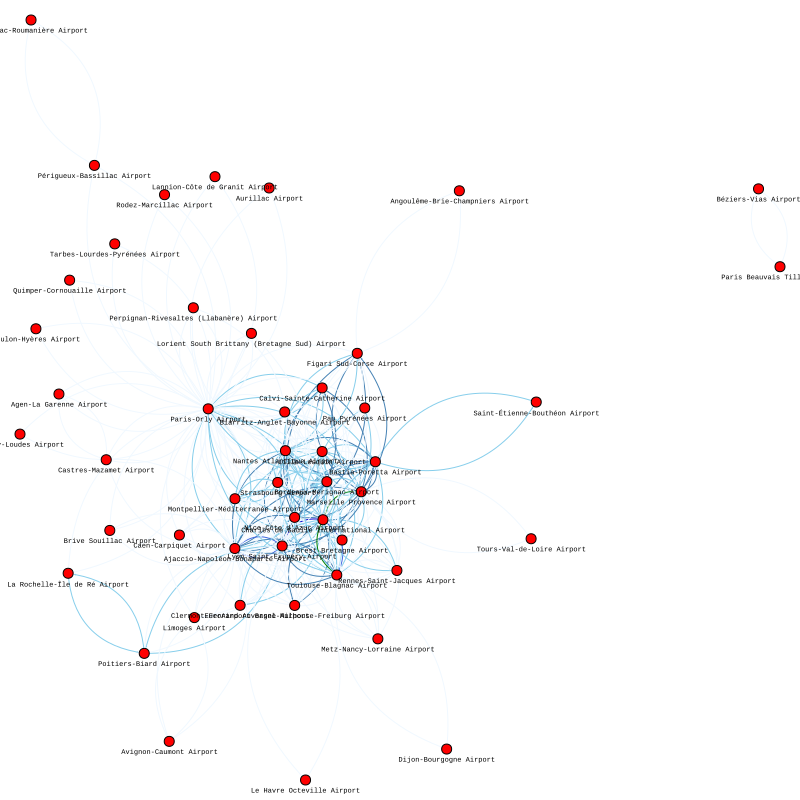

In [21]:
# Definisci una mappatura dei colori per i diversi pesi degli archi
import matplotlib.pyplot as plt

#print(df_merged['weight'].describe())
edge_colors = {
    1: '#f0f8ff',  # Azzurro molto chiaro
    2: '#add8e6',  # Azzurro chiaro
    3: '#87ceeb',  # Azzurro moderato
    4: '#4682b4',  # Blu acciaio
    5: '#4169e1',  # Blu reale
    6: '#0000cd',  # Blu medio
    7: 'black',    # Nero
    8: '#808000',  # Verde oliva
    9: '#008000'   # Verde smeraldo
}

color_legend = [
    (1, '#f0f8ff'),  # Azzurro molto chiaro
    (2, '#add8e6'),  # Azzurro chiaro
    (3, '#87ceeb'),  # Azzurro moderato
    (4, '#4682b4'),  # Blu acciaio
    (5, '#4169e1'),  # Blu reale
    (6, '#0000cd'),  # Blu medio
    (7, 'black'),    # Nero
    (8, '#808000'),  # Verde oliva
    (9, '#008000')   # Verde smeraldo
]

# Creiamo una legenda personalizzata
legend_elements = [plt.Line2D([0], [0], marker='o', color=color, label=f'Peso {weight}', markersize=10)
                   for weight, color in color_legend]

# Visualizziamo la legenda senza assi

plt.axis('off')  # Rimuove gli assi

plt.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(1, 0))
plt.show()

# Mostrare il grafico
ig.plot(g
        , vertex_label=g.vs['name']
        , vertex_label_dist=1.5
        #, layout=g.layout('fruchterman_reingold')
        , bbox=(800, 800)
        , margin=20
        , vertex_size=10
        , edge_arrow_size=0.2
        , edge_curved=True
        #, edge_label=g.es['weight']
        , edge_label_dist= 2
        , vertex_label_size= 7
        , edge_label_size= 5
        , edge_color=[edge_colors[weight] for weight in g.es['weight']]
        )


In [22]:
processed_nodes = set()

# Aggiungi attributi ai nodi senza duplicati
for _, row in df_merged.iterrows():
    # Nodo di partenza
    source_id = row['Source airport name']
    if source_id not in processed_nodes:  # Aggiungi attributi solo se non è stato già processato
        g.vs.find(name=source_id)['city'] = row['Source airport city']
        g.vs.find(name=source_id)['country'] = row['Source airport country']

        processed_nodes.add(source_id)  # Aggiungi il nodo al set dei nodi già processati

    # Nodo di arrivo
    destination_id = row['Destination airport name']
    if destination_id not in processed_nodes:
        g.vs.find(name=destination_id)['city'] = row['Destination airport city']
        g.vs.find(name=destination_id)['country'] = row['Destination airport country']

        processed_nodes.add(destination_id)  # Aggiungi anche questo nodo al set

In [23]:
for node in g.vs:
    # Usa 'attributes()' per ottenere tutti gli attributi del nodo
    attributes = node.attributes()
    print(f"Nodo {node['name']} ha attributi: {attributes}")

Nodo Bordeaux-Mérignac Airport ha attributi: {'name': 'Bordeaux-Mérignac Airport', 'city': 'Bordeaux', 'country': 'France'}
Nodo Lille-Lesquin Airport ha attributi: {'name': 'Lille-Lesquin Airport', 'city': 'Lille', 'country': 'France'}
Nodo Lyon Saint-Exupéry Airport ha attributi: {'name': 'Lyon Saint-Exupéry Airport', 'city': 'Lyon', 'country': 'France'}
Nodo Montpellier-Méditerranée Airport ha attributi: {'name': 'Montpellier-Méditerranée Airport', 'city': 'Montpellier', 'country': 'France'}
Nodo Toulouse-Blagnac Airport ha attributi: {'name': 'Toulouse-Blagnac Airport', 'city': 'Toulouse', 'country': 'France'}
Nodo Bastia-Poretta Airport ha attributi: {'name': 'Bastia-Poretta Airport', 'city': 'Bastia', 'country': 'France'}
Nodo Nice-Côte d'Azur Airport ha attributi: {'name': "Nice-Côte d'Azur Airport", 'city': 'Nice', 'country': 'France'}
Nodo Marseille Provence Airport ha attributi: {'name': 'Marseille Provence Airport', 'city': 'Marseille', 'country': 'France'}
Nodo Nantes Atlan

Misure di **Centralità**

Grado

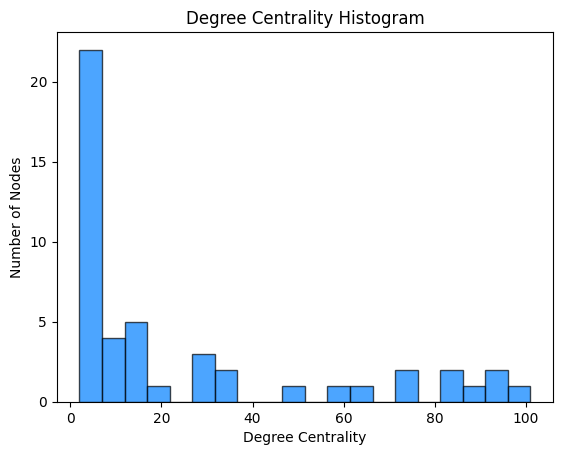

In [24]:
#grado, considerando i pesi
degree_sequence = g.strength(mode = 'all', weights='weight')

# Visualizza l'istogramma del conteggio dei gradi
plt.hist(degree_sequence, bins=20, alpha=0.7, color='#007FFF', edgecolor='black')
plt.xlabel('Degree Centrality')
plt.ylabel('Number of Nodes')
plt.title('Degree Centrality Histogram')
plt.grid(False)

plt.show()


In [25]:
# Ottieni i nomi dei nodi
nomi_nodi = g.vs["name"]

# Creazione della struttura dati (dizionario) per salvare nome del nodo e grado
struttura_dati = {}

# Associazione di nome del nodo al suo grado nel dizionario
for nome, grado in zip(nomi_nodi, degree_sequence):
    struttura_dati[nome] = grado

struttura_dati_ordinata_g = sorted(struttura_dati.items(), key=lambda item: item[1], reverse=True)
nomi_nodi_ordinati_g = [item[0] for item in struttura_dati_ordinata_g]

# Stampa dei nomi dei nodi ordinati
print("Nomi dei nodi ordinati per grado decrescente:")
for nodo in nomi_nodi_ordinati_g:
    print(nodo)
    #print(struttura_dati[nodo])
print(struttura_dati)

Nomi dei nodi ordinati per grado decrescente:
Charles de Gaulle International Airport
Lyon Saint-Exupéry Airport
Nice-Côte d'Azur Airport
Marseille Provence Airport
Nantes Atlantique Airport
Paris-Orly Airport
Ajaccio-Napoléon Bonaparte Airport
Toulouse-Blagnac Airport
Bastia-Poretta Airport
Bordeaux-Mérignac Airport
Lille-Lesquin Airport
Strasbourg Airport
Calvi-Sainte-Catherine Airport
Figari Sud-Corse Airport
Montpellier-Méditerranée Airport
Brest Bretagne Airport
EuroAirport Basel-Mulhouse-Freiburg Airport
Rennes-Saint-Jacques Airport
Biarritz-Anglet-Bayonne Airport
Poitiers-Biard Airport
Clermont-Ferrand Auvergne Airport
Pau Pyrénées Airport
Caen-Carpiquet Airport
Metz-Nancy-Lorraine Airport
Limoges Airport
La Rochelle-Île de Ré Airport
Castres-Mazamet Airport
Saint-Étienne-Bouthéon Airport
Lorient South Brittany (Bretagne Sud) Airport
Perpignan-Rivesaltes (Llabanère) Airport
Agen-La Garenne Airport
Brive Souillac Airport
Périgueux-Bassillac Airport
Avignon-Caumont Airport
Le Havr

Betweenness

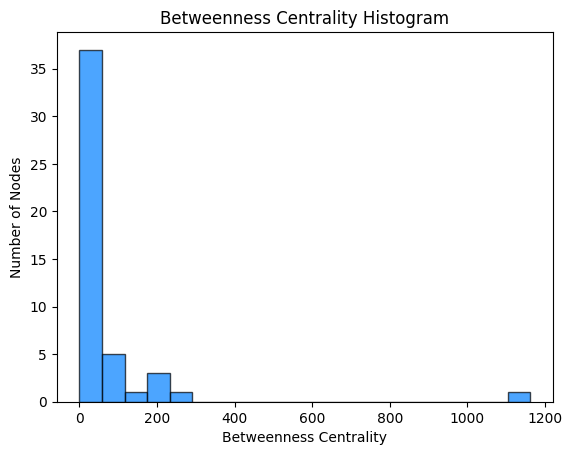

In [26]:
# Calcolo della betweenness con igraph
betweenness = g.betweenness(directed=True, weights= 'weight')

# Creazione dell'istogramma
plt.hist(betweenness, bins=20, alpha=0.7, color='#007FFF', edgecolor='black')
plt.xlabel('Betweenness Centrality')
plt.ylabel('Number of Nodes')
plt.title('Betweenness Centrality Histogram')
#plt.grid(False)
plt.show()

In [27]:
# Ottieni i nomi dei nodi
nomi_nodi = g.vs["name"]

# Creazione della struttura dati (dizionario) per salvare nome del nodo e grado
struttura_dati = {}

# Associazione di nome del nodo al suo grado nel dizionario
for nome, betweenne in zip(nomi_nodi, betweenness):
    struttura_dati[nome] = betweenne

struttura_dati_ordinata_b = sorted(struttura_dati.items(), key=lambda item: item[1], reverse=True)
nomi_nodi_ordinati_b = [item[0] for item in struttura_dati_ordinata_b]

# Stampa dei nomi dei nodi ordinati
print("Nomi dei nodi ordinati per grado decrescente:")
for nodo in nomi_nodi_ordinati_b:
    print(nodo)
    #print(struttura_dati[nodo])

Nomi dei nodi ordinati per grado decrescente:
Paris-Orly Airport
Lyon Saint-Exupéry Airport
Strasbourg Airport
Ajaccio-Napoléon Bonaparte Airport
Bordeaux-Mérignac Airport
Marseille Provence Airport
Toulouse-Blagnac Airport
Figari Sud-Corse Airport
Bastia-Poretta Airport
Périgueux-Bassillac Airport
Biarritz-Anglet-Bayonne Airport
Limoges Airport
Nice-Côte d'Azur Airport
EuroAirport Basel-Mulhouse-Freiburg Airport
Brest Bretagne Airport
Montpellier-Méditerranée Airport
Lille-Lesquin Airport
Rennes-Saint-Jacques Airport
Charles de Gaulle International Airport
Nantes Atlantique Airport
Caen-Carpiquet Airport
Castres-Mazamet Airport
Metz-Nancy-Lorraine Airport
Pau Pyrénées Airport
Brive Souillac Airport
Clermont-Ferrand Auvergne Airport
Avignon-Caumont Airport
Calvi-Sainte-Catherine Airport
Lorient South Brittany (Bretagne Sud) Airport
Poitiers-Biard Airport
Le Havre Octeville Airport
Perpignan-Rivesaltes (Llabanère) Airport
Tours-Val-de-Loire Airport
Agen-La Garenne Airport
Aurillac Airpo

Reciprocità e Assortatività

In [28]:
reciprocity = g.reciprocity()
print(f"Reciprocity: {reciprocity}")

degree_assortativity = g.assortativity_degree()
print(f"Degree Assortativity: {degree_assortativity}")

Reciprocity: 1.0
Degree Assortativity: -0.4535653321067215


Analisi della rete

In [29]:
# Trova tutte le componenti connesse
components = g.connected_components()
# Conta il numero di nodi in ogni componente
component_sizes = [len(component) for component in components]

# Stampa le dimensioni di ogni componente
for i, size in enumerate(component_sizes):
    print(f"Component {i+1} has {size} nodes")



Component 1 has 2 nodes
Component 2 has 46 nodes


In [30]:
# Trova la giant component massima
giant_component = components.giant()

# Calcola il diametro della giant component massima
diameter = giant_component.diameter()

print(f"Il diametro della giant component massima è: {diameter}")

Il diametro della giant component massima è: 4


In [31]:
# Calcola la lunghezza media dei cammini
avg_path_length = g.average_path_length()

print("Lunghezza media dei cammini:", avg_path_length)

Lunghezza media dei cammini: 2.1254826254826256


In [32]:
# Funzione per calcolare l'efficienza globale di un grafo
def calculate_global_efficiency(graph):
    n = len(graph.vs)
    if n < 2:
        return 0
    inv_distances = []
    shortest_paths = graph.shortest_paths()
    for row in shortest_paths:
        inv_distances.extend([1/d for d in row if d > 0])
    efficiency = sum(inv_distances) / (n * (n - 1))
    return efficiency

# Calcola l'efficienza globale del grafo
efficiency = calculate_global_efficiency(g)

print("Efficienza globale:", efficiency)

Efficienza globale: 0.4874408983451533


<ipython-input-32-3806aaa81a8d>:7: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = graph.shortest_paths()


Attacchi alla rete

In [33]:
import random
import numpy as np

def remove_edges_of_node(graph, node_name):
    node = graph.vs.find(name=node_name)
    edges_from_source = graph.es.select(_source=node.index)
    edges_from_target = graph.es.select(_target=node.index)
    edges_to_remove_indices = [edge.index for edge in edges_from_source] + [edge.index for edge in edges_from_target]
    graph.delete_edges(edges_to_remove_indices)

def simulate_attack(graph, num_attacks, nodi_ordinati=[]):
    original_graph = graph.copy()
    initial_metrics = {
        'giant_component_size': [],
        'edge_count': [],
        'diameter': [],
        'avg_path_length': [],
        'efficiency': [],
        'nodes_removed_percentage': []
    }

    initial_giant_component = graph.components().giant()
    initial_giant_component_size = len(initial_giant_component.vs)
    initial_edge_count = sum(edge['weight'] for edge in graph.es)
    initial_diameter = initial_giant_component.diameter()
    initial_avg_path_length = graph.average_path_length()
    initial_efficiency = calculate_global_efficiency(graph)

    initial_metrics['giant_component_size'].append(initial_giant_component_size)
    initial_metrics['edge_count'].append(initial_edge_count)
    initial_metrics['diameter'].append(initial_diameter)
    initial_metrics['avg_path_length'].append(initial_avg_path_length)
    initial_metrics['efficiency'].append(initial_efficiency)
    initial_metrics['nodes_removed_percentage'].append(0)  # Inizialmente, nessun nodo è stato rimosso

    removed_nodes = []
    removed_node_names = []

    for attack in range(num_attacks):
        if len(nodi_ordinati) > 0:
            node_to_remove = nodi_ordinati.pop(0)
        else:
            if len(graph.vs) == 0:
                break
            node_to_remove = random.choice(graph.vs)['name']

        removed_nodes.append(node_to_remove)
        removed_node_names.append(node_to_remove)
        graph.delete_vertices(node_to_remove)
        remove_edges_of_node(original_graph, node_to_remove)

        if len(graph.vs) == 0:
            break

        giant_component = graph.components().giant() if len(graph.components()) > 0 else ig.Graph()
        giant_component_size = len(giant_component.vs)
        edge_count = sum(edge['weight'] for edge in graph.es)
        diameter = giant_component.diameter() if giant_component_size > 1 else 0
        avg_path_length = graph.average_path_length() if len(graph.vs) > 1 else 0
        efficiency = calculate_global_efficiency(graph)

        initial_metrics['giant_component_size'].append(float(f"{giant_component_size:.3f}"))
        initial_metrics['edge_count'].append(float(f"{edge_count:.3f}"))
        initial_metrics['diameter'].append(float(f"{diameter:.3f}"))
        initial_metrics['avg_path_length'].append(float(f"{avg_path_length:.3f}"))
        initial_metrics['efficiency'].append(float(f"{efficiency:.3f}"))
        nodes_removed_percentage = (len(removed_nodes) / initial_giant_component_size) * 100
        initial_metrics['nodes_removed_percentage'].append(float(f"{nodes_removed_percentage:.3f}"))

    #countryg = graph.vs["country"]
    franceg = graph.vs["name"]
    final_giant_component = graph.components().giant() if len(graph.components()) > 0 else ig.Graph()
    #country_values = final_giant_component.vs["country"]
    name_values = final_giant_component.vs["name"]
    not_in_name_france = [name for name in franceg if name not in name_values]
    #not_in_country_values = [country for country in countryg if country not in country_values]

    original_graph.vs["color"] = "white"
    for v in original_graph.vs:
        if v["name"] in removed_node_names:
            v["color"] = "red"
        elif v["name"] in name_values:
            v["color"] = "green"

    layout = original_graph.layout("fr")

    return {
        "graph": original_graph,
        "removed_nodes": removed_nodes,
        "metrics": initial_metrics,
        "lista aereoporti francesi non presenti nella giant component": not_in_name_france
    }

Casuali

In [34]:
# Simula un attacco rimuovendo dei nodi
results = simulate_attack(g.copy(), 15,[])
metrics_random = results["metrics"]
print(results)

{'graph': <igraph.Graph object at 0x7958c3c6ed40>, 'removed_nodes': ['Toulouse-Blagnac Airport', 'Aurillac Airport', 'Bordeaux-Mérignac Airport', 'Toulon-Hyères Airport', 'Paris-Orly Airport', 'Strasbourg Airport', 'Paris Beauvais Tillé Airport', 'Rennes-Saint-Jacques Airport', 'Calvi-Sainte-Catherine Airport', 'Limoges Airport', 'Lyon Saint-Exupéry Airport', 'Pau Pyrénées Airport', 'Lorient South Brittany (Bretagne Sud) Airport', 'Metz-Nancy-Lorraine Airport', "Nice-Côte d'Azur Airport"], 'metrics': {'giant_component_size': [46, 44.0, 43.0, 42.0, 41.0, 33.0, 32.0, 32.0, 31.0, 30.0, 29.0, 26.0, 25.0, 25.0, 24.0, 23.0], 'edge_count': [602, 530.0, 528.0, 470.0, 468.0, 394.0, 368.0, 366.0, 354.0, 330.0, 324.0, 252.0, 244.0, 244.0, 240.0, 188.0], 'diameter': [4, 4.0, 4.0, 4.0, 4.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0], 'avg_path_length': [2.1254826254826256, 2.115, 2.108, 2.13, 2.123, 2.204, 2.229, 2.231, 2.236, 2.234, 2.236, 2.304, 2.296, 2.296, 2.285, 2.378], 'efficienc

<ipython-input-32-3806aaa81a8d>:7: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = graph.shortest_paths()


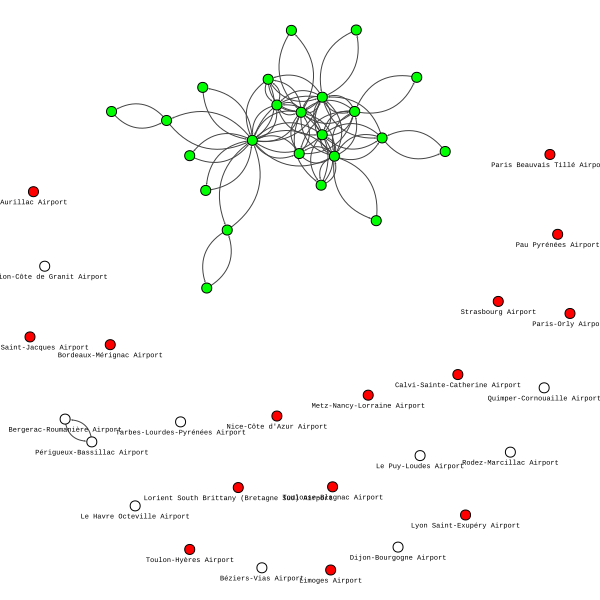

In [35]:
vertex_labels = [
    name if color != 'green' else ''
    for name, color in zip(results["graph"].vs['name'], results["graph"].vs['color'])
]

ig.plot(results["graph"]
        , vertex_label = vertex_labels
        , vertex_label_dist = 1.5
        , bbox=(600, 600)
        , margin=30
        , vertex_size= 10
        , edge_arrow_size=0.2
        , edge_curved=True
        , edge_label_dist= 2
        , vertex_label_size= 7
        , edge_label_size= 5
        ,vertex_color = results["graph"].vs["color"]
        )

Mirati

In [36]:
# Simula un attacco rimuovendo dei nodi secondo l'ordine del grado
results = simulate_attack(g.copy(), 15, nomi_nodi_ordinati_g)
metrics_ordered_g = results["metrics"]
print(results)

{'graph': <igraph.Graph object at 0x7958c3c6f240>, 'removed_nodes': ['Charles de Gaulle International Airport', 'Lyon Saint-Exupéry Airport', "Nice-Côte d'Azur Airport", 'Marseille Provence Airport', 'Nantes Atlantique Airport', 'Paris-Orly Airport', 'Ajaccio-Napoléon Bonaparte Airport', 'Toulouse-Blagnac Airport', 'Bastia-Poretta Airport', 'Bordeaux-Mérignac Airport', 'Lille-Lesquin Airport', 'Strasbourg Airport', 'Calvi-Sainte-Catherine Airport', 'Figari Sud-Corse Airport', 'Montpellier-Méditerranée Airport'], 'metrics': {'giant_component_size': [46, 45.0, 43.0, 42.0, 40.0, 39.0, 25.0, 16.0, 13.0, 11.0, 7.0, 4.0, 2.0, 2.0, 2.0, 2.0], 'edge_count': [602, 501.0, 416.0, 336.0, 262.0, 202.0, 130.0, 96.0, 74.0, 56.0, 34.0, 26.0, 18.0, 18.0, 16.0, 14.0], 'diameter': [4, 4.0, 4.0, 4.0, 4.0, 4.0, 5.0, 4.0, 4.0, 3.0, 4.0, 3.0, 1.0, 1.0, 1.0, 1.0], 'avg_path_length': [2.1254826254826256, 2.135, 2.159, 2.198, 2.218, 2.247, 2.517, 2.104, 1.976, 1.9, 1.769, 1.333, 1.0, 1.0, 1.0, 1.0], 'efficiency

<ipython-input-32-3806aaa81a8d>:7: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = graph.shortest_paths()


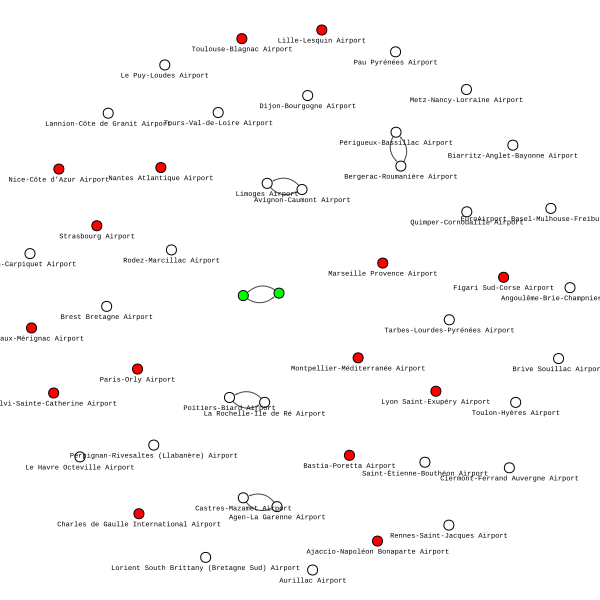

In [37]:
vertex_labels = [
    name if color != 'green' else ''
    for name, color in zip(results["graph"].vs['name'], results["graph"].vs['color'])
]

ig.plot(results["graph"]
        , vertex_label = vertex_labels
        , vertex_label_dist = 1.5
        , bbox=(600, 600)
        , margin=30
        , vertex_size= 10
        , edge_arrow_size=0.2
        , edge_curved=True
        , edge_label_dist= 2
        , vertex_label_size= 7
        , edge_label_size= 5
        ,vertex_color = results["graph"].vs["color"]
        )

In [38]:
# Simula un attacco rimuovendo dei nodi secondo l'ordine della betweenness
results = simulate_attack(g.copy(), 15, nomi_nodi_ordinati_b)
metrics_ordered_b = results["metrics"]
print(results)

{'graph': <igraph.Graph object at 0x7958c3c6f040>, 'removed_nodes': ['Paris-Orly Airport', 'Lyon Saint-Exupéry Airport', 'Strasbourg Airport', 'Ajaccio-Napoléon Bonaparte Airport', 'Bordeaux-Mérignac Airport', 'Marseille Provence Airport', 'Toulouse-Blagnac Airport', 'Figari Sud-Corse Airport', 'Bastia-Poretta Airport', 'Périgueux-Bassillac Airport', 'Biarritz-Anglet-Bayonne Airport', 'Limoges Airport', "Nice-Côte d'Azur Airport", 'EuroAirport Basel-Mulhouse-Freiburg Airport', 'Brest Bretagne Airport'], 'metrics': {'giant_component_size': [46, 36.0, 33.0, 32.0, 26.0, 25.0, 23.0, 21.0, 19.0, 17.0, 17.0, 16.0, 14.0, 11.0, 10.0, 9.0], 'edge_count': [602, 516.0, 424.0, 392.0, 334.0, 292.0, 225.0, 179.0, 161.0, 129.0, 127.0, 121.0, 117.0, 79.0, 67.0, 61.0], 'diameter': [4, 5.0, 5.0, 5.0, 5.0, 5.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 3.0, 3.0, 3.0, 3.0], 'avg_path_length': [2.1254826254826256, 2.176, 2.232, 2.261, 2.076, 2.112, 2.125, 2.112, 2.034, 1.986, 1.993, 2.0, 1.819, 1.828, 1.854, 1.795], '

<ipython-input-32-3806aaa81a8d>:7: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = graph.shortest_paths()


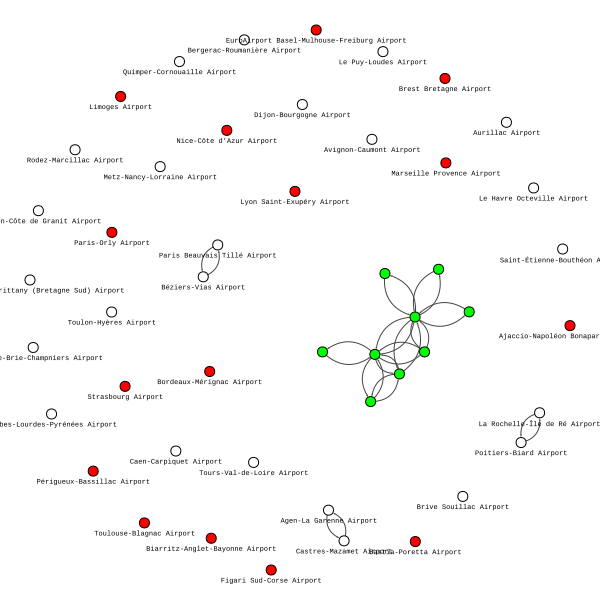

In [39]:
vertex_labels = [
    name if color != 'green' else ''
    for name, color in zip(results["graph"].vs['name'], results["graph"].vs['color'])
]

ig.plot(results["graph"]
        , vertex_label = vertex_labels
        , vertex_label_dist = 1.5
        , bbox=(600, 600)
        , margin=30
        , vertex_size= 10
        , edge_arrow_size=0.2
        , edge_curved=True
        , edge_label_dist= 2
        , vertex_label_size= 7
        , edge_label_size= 5
        ,vertex_color = results["graph"].vs["color"]
        )

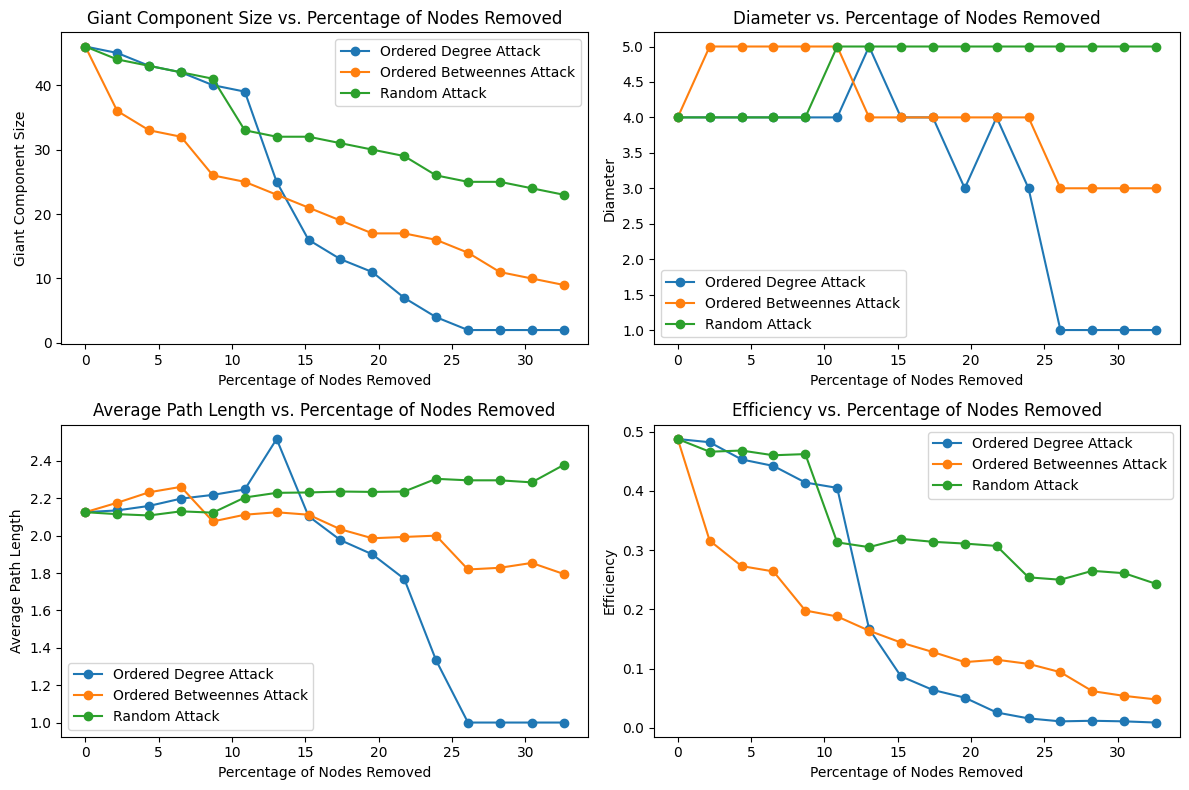

In [40]:
# Creazione dei grafici
import matplotlib.pyplot as plt

# Creazione dei grafici
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(metrics_ordered_g['nodes_removed_percentage'], metrics_ordered_g['giant_component_size'], marker='o', label='Ordered Degree Attack')
plt.plot(metrics_ordered_b['nodes_removed_percentage'], metrics_ordered_b['giant_component_size'], marker='o', label='Ordered Betweennes Attack')
plt.plot(metrics_random['nodes_removed_percentage'], metrics_random['giant_component_size'], marker='o', label='Random Attack')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Giant Component Size')
plt.title('Giant Component Size vs. Percentage of Nodes Removed')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(metrics_ordered_g['nodes_removed_percentage'], metrics_ordered_g['diameter'], marker='o', label='Ordered Degree Attack')
plt.plot(metrics_ordered_b['nodes_removed_percentage'], metrics_ordered_b['diameter'], marker='o', label='Ordered Betweennes Attack')
plt.plot(metrics_random['nodes_removed_percentage'], metrics_random['diameter'], marker='o', label='Random Attack')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Diameter')
plt.title('Diameter vs. Percentage of Nodes Removed')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(metrics_ordered_g['nodes_removed_percentage'], metrics_ordered_g['avg_path_length'], marker='o', label='Ordered Degree Attack')
plt.plot(metrics_ordered_b['nodes_removed_percentage'], metrics_ordered_b['avg_path_length'], marker='o', label='Ordered Betweennes Attack')
plt.plot(metrics_random['nodes_removed_percentage'], metrics_random['avg_path_length'], marker='o', label='Random Attack')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Average Path Length')
plt.title('Average Path Length vs. Percentage of Nodes Removed')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(metrics_ordered_g['nodes_removed_percentage'], metrics_ordered_g['efficiency'], marker='o', label='Ordered Degree Attack')
plt.plot(metrics_ordered_b['nodes_removed_percentage'], metrics_ordered_b['efficiency'], marker='o', label='Ordered Betweennes Attack')
plt.plot(metrics_random['nodes_removed_percentage'], metrics_random['efficiency'], marker='o', label='Random Attack')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Efficiency')
plt.title('Efficiency vs. Percentage of Nodes Removed')
plt.legend()

plt.tight_layout()
plt.show()

**Sezione sulle compagnie aeree**

In [41]:
#import del db airlines, per avere informazioni sulle compagnie aeree
df_airlines = pd.read_csv("drive/MyDrive/Progetto Data Analytics/airlines.csv")
#df_airlines

In [42]:
# Tieni solo le colonne 'Airline ID' e 'Name'
df_airlines = df_airlines[['Airline ID', 'Name']]
#df_airlines

In [43]:
df_routes_edge = df_routes_ori.loc[:, ['Airline ID', 'Source airport', 'Source airport ID', 'Destination airport', 'Destination airport ID']]
#df_routes_edge.head()

In [44]:
number_of_rows = df_routes_edge.shape[0]
number_of_rows

67652

In [45]:
# Eliminiamo i record con 'Source Airport ID' uguale a '\N'
df_routes_edge = df_routes_edge[df_routes_edge['Source airport ID'] != '\\N']

# Eliminiamo i record con 'Destination Airport ID' uguale a '\N'
df_routes_edge = df_routes_edge[df_routes_edge['Destination airport ID'] != '\\N']

# Eliminiamo i record con 'Destination Airport ID' uguale a '\N'
df_routes_edge = df_routes_edge[df_routes_edge['Airline ID'] != '\\N']

# Trasformiamo la colonna 'Destination Airport ID' in tipo int64
df_routes_edge['Airline ID'] = df_routes_edge['Airline ID'].astype('int64')

# Trasformiamo la colonna 'Source Airport ID' in tipo int64
df_routes_edge['Source airport ID'] = df_routes_edge['Source airport ID'].astype('int64')

# Trasformiamo la colonna 'Destination Airport ID' in tipo int64
df_routes_edge['Destination airport ID'] = df_routes_edge['Destination airport ID'].astype('int64')

In [46]:
number_of_rows = df_routes_edge.shape[0]
number_of_rows

66754

Creazione di un unico dataset

In [47]:
# Eseguiamo l'inner join sugli aeroporti di partenza
df_merged_edge = pd.merge(df_routes_edge, df_airports, left_on='Source airport ID', right_on='Airport ID', how='inner')
#df_merged_edge

In [48]:
# Rimuoviamo la colonna 'Airport ID' da df_merged, in quanto ripetizione di source airport id
df_merged_edge = df_merged_edge.drop(columns=['Airport ID'])

# Rinominiamo le colonne, in vista della seconda merge
df_merged_edge = df_merged_edge.rename(columns={
    'Name': 'Source airport name',
    'City': 'Source airport city',
    'Country': 'Source airport country'
})

#df_merged_edge.head()

In [49]:
# Eseguiamo l'inner join sugli aeroporti di destinazione
df_merged_edge = pd.merge(df_merged_edge, df_airports, left_on='Destination airport ID', right_on='Airport ID', how='inner')
#df_merged_edge

In [50]:
# Rimuoviamo la colonna 'Airport ID' da df_merged, in quanto ripetizione di source airport id
df_merged_edge = df_merged_edge.drop(columns=['Airport ID'])

# Rinominiamo le colonne
df_merged_edge = df_merged_edge.rename(columns={
    'Name': 'Destination airport name',
    'City': 'Destination airport city',
    'Country': 'Destination airport country'
})

#df_merged_edge

In [51]:
# Eseguiamo l'inner join sulle compagnie aeree
df_merged_edge = pd.merge(df_merged_edge, df_airlines, left_on='Airline ID', right_on='Airline ID', how='inner')
#df_merged_edge

In [52]:
df_merged_edge = df_merged_edge.rename(columns={
    'Name': 'Airline name'
})
df_merged_edge

,Airline ID,Source airport,Source airport ID,Destination airport,Destination airport ID,Source airport name,Source airport city,Source airport country,Destination airport name,Destination airport city,Destination airport country,Airline name
0,1203,BOD,1264,LIL,1399,Bordeaux-Mérignac Airport,Bordeaux,France,Lille-Lesquin Airport,Lille,France,Airlinair
1,1203,LYS,1335,LIL,1399,Lyon Saint-Exupéry Airport,Lyon,France,Lille-Lesquin Airport,Lille,France,Airlinair
2,1203,MPL,1359,LIL,1399,Montpellier-Méditerranée Airport,Montpellier,France,Lille-Lesquin Airport,Lille,France,Airlinair
3,1203,TLS,1273,LIL,1399,Toulouse-Blagnac Airport,Toulouse,France,Lille-Lesquin Airport,Lille,France,Airlinair
4,1203,BIA,1321,LIL,1399,Bastia-Poretta Airport,Bastia,France,Lille-Lesquin Airport,Lille,France,Airlinair
...,...,...,...,...,...,...,...,...,...,...,...,...
478,2421,MRS,1353,ORY,1386,Marseille Provence Airport,Marseille,France,Paris-Orly Airport,Paris,France,Flybe
479,2757,LPY,1313,ORY,1386,Le Puy-Loudes Airport,Le Puy,France,Paris-Orly Airport,Paris,France,Hex'Air
480,2757,ORY,1386,LPY,1313,Paris-Orly Airport,Paris,France,Le Puy-Loudes Airport,Le Puy,France,Hex'Air
481,3329,ANG,1277,FSC,1323,Angoulême-Brie-Champniers Airport,Angouleme,France,Figari Sud-Corse Airport,Figari,France,Luxair


In [53]:
names = df_merged_edge['Airline name']
airline_counts = names.value_counts()
print(airline_counts)

#sum(name_counts)

Airline name
Airlinair                    116
Air France                   116
easyJet                       56
VOLOTEA Airways               48
Alitalia                      38
Corse-Mediterranee            36
Twin Jet                      16
Ryanair                       12
Nationwide Airlines           10
XL Airways France              5
Eastern Airways                4
Aeroflot Russian Airlines      3
Delta Air Lines                3
AeroMéxico                     3
Etihad Airways                 2
Air Mauritius                  2
Hex'Air                        2
Luxair                         2
KLM Royal Dutch Airlines       2
Japan Airlines                 2
Harmony Airways                2
Finnair                        1
Flybe                          1
Nouvel Air Tunisie             1
Name: count, dtype: int64


Airline name
Airlinair                    116
Air France                   116
easyJet                       56
VOLOTEA Airways               48
Alitalia                      38
Corse-Mediterranee            36
Twin Jet                      16
Ryanair                       12
Nationwide Airlines           10
XL Airways France              5
Eastern Airways                4
Aeroflot Russian Airlines      3
Delta Air Lines                3
AeroMéxico                     3
Etihad Airways                 2
Air Mauritius                  2
Hex'Air                        2
Luxair                         2
KLM Royal Dutch Airlines       2
Japan Airlines                 2
Harmony Airways                2
Finnair                        1
Flybe                          1
Nouvel Air Tunisie             1
Name: count, dtype: int64


<ipython-input-54-0be8069d3473>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airline_counts.index, y=airline_counts.values, palette='viridis')


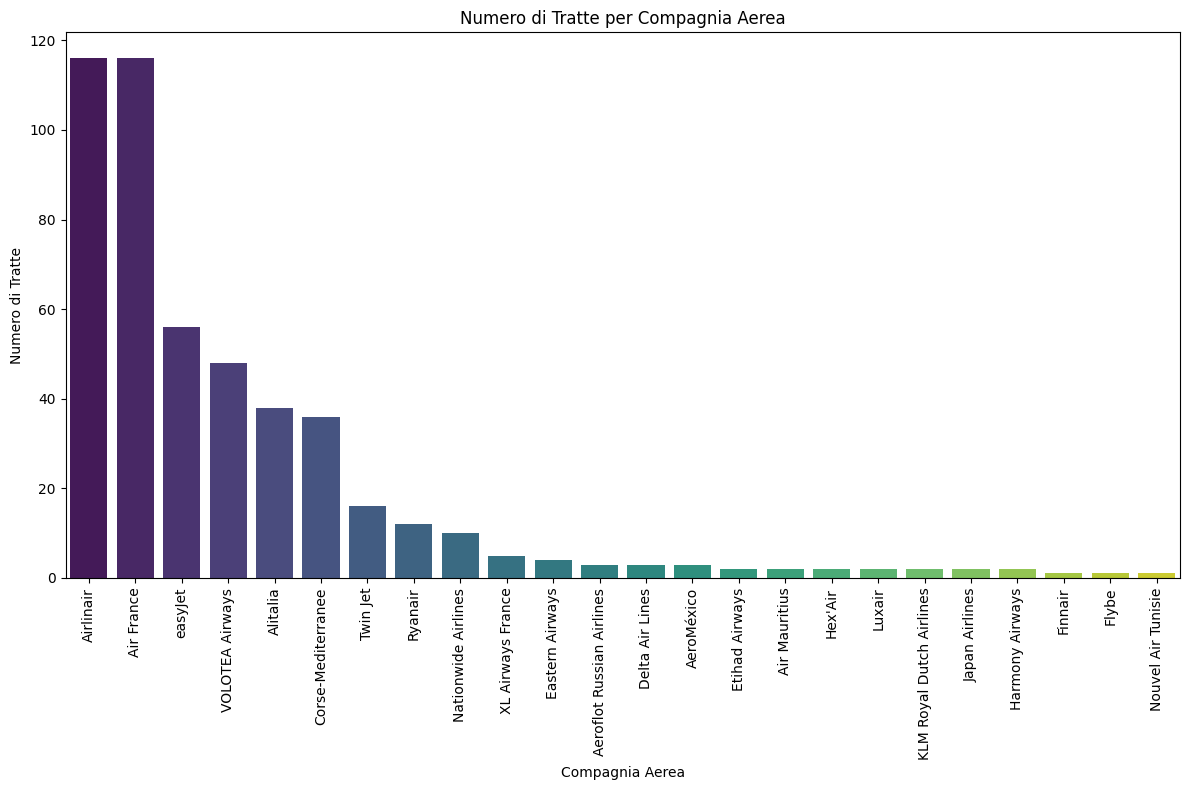

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Supponendo che df_merged_edge sia il DataFrame con i dati delle tratte
names = df_merged_edge['Airline name']
airline_counts = names.value_counts()

# Stampa il conteggio delle tratte per ogni compagnia aerea
print(airline_counts)

# Crea l'istogramma
plt.figure(figsize=(12, 8))
sns.barplot(x=airline_counts.index, y=airline_counts.values, palette='viridis')

# Aggiungi etichette e titolo
plt.xlabel('Compagnia Aerea')
plt.ylabel('Numero di Tratte')
plt.title('Numero di Tratte per Compagnia Aerea')
plt.xticks(rotation=90)

# Mostra il grafico
plt.tight_layout()
plt.show()


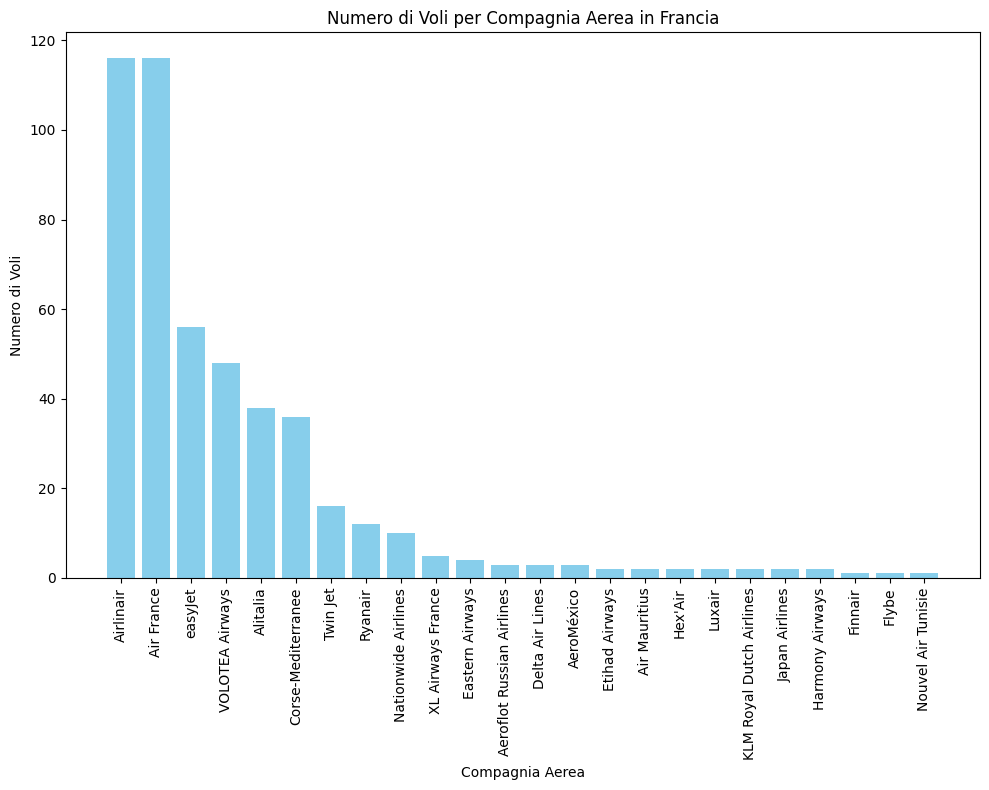

In [55]:
import matplotlib.pyplot as plt

# Dati delle compagnie aeree e numero di voli
compagnie_aeree = [
    'Airlinair', 'Air France', 'easyJet', 'VOLOTEA Airways', 'Alitalia',
    'Corse-Mediterranee', 'Twin Jet', 'Ryanair', 'Nationwide Airlines',
    'XL Airways France', 'Eastern Airways', 'Aeroflot Russian Airlines',
    'Delta Air Lines', 'AeroMéxico', 'Etihad Airways', 'Air Mauritius',
    'Hex\'Air', 'Luxair', 'KLM Royal Dutch Airlines', 'Japan Airlines',
    'Harmony Airways', 'Finnair', 'Flybe', 'Nouvel Air Tunisie'
]

numero_voli = [
    116, 116, 56, 48, 38, 36, 16, 12, 10, 5, 4, 3, 3, 3, 2, 2, 2, 2, 2, 2,
    2, 1, 1, 1
]

# Creazione del grafico a barre
plt.figure(figsize=(10, 8))
plt.bar(compagnie_aeree, numero_voli, color='skyblue')

# Ruotare i nomi delle compagnie aeree sull'asse x
plt.xticks(rotation=90)

# Etichettare gli assi
plt.xlabel('Compagnia Aerea')
plt.ylabel('Numero di Voli')
plt.title('Numero di Voli per Compagnia Aerea in Francia')

# Visualizzare il grafico
plt.tight_layout()
plt.show()


In [56]:
# Ottieni i nomi delle compagnie aeree
names = df_merged_edge['Airline name']
# Conta la frequenza di ciascun nome
airline_counts = names.value_counts()
# Crea un array dei nomi delle compagnie aeree ordinati in ordine decrescente di frequenza
ordered_airlines = airline_counts.index.tolist()

print(ordered_airlines)

['Airlinair', 'Air France', 'easyJet', 'VOLOTEA Airways', 'Alitalia', 'Corse-Mediterranee', 'Twin Jet', 'Ryanair', 'Nationwide Airlines', 'XL Airways France', 'Eastern Airways', 'Aeroflot Russian Airlines', 'Delta Air Lines', 'AeroMéxico', 'Etihad Airways', 'Air Mauritius', "Hex'Air", 'Luxair', 'KLM Royal Dutch Airlines', 'Japan Airlines', 'Harmony Airways', 'Finnair', 'Flybe', 'Nouvel Air Tunisie']


Creazione del grafo

In [57]:
# Crea un grafo vuoto
g_airlines = ig.Graph(directed=True)

# Aggiungi nodi
nodi = pd.unique(df_merged_edge[['Source airport name', 'Destination airport name']].values.ravel('K'))
g_airlines.add_vertices(nodi)

# Aggiungi archi e pesi
for _, row in df_merged_edge.iterrows():
    source_id = row['Source airport name']
    dest_id = row['Destination airport name']
    g_airlines.add_edge(source_id, dest_id, Airline_name=row['Airline name'])

# Verifica gli archi con attributi 'None'
for edge in g_airlines.es:
    if edge['Airline_name'] is None:
        print(f"Arco con Airline_name None: {edge.source} -> {edge.target}")



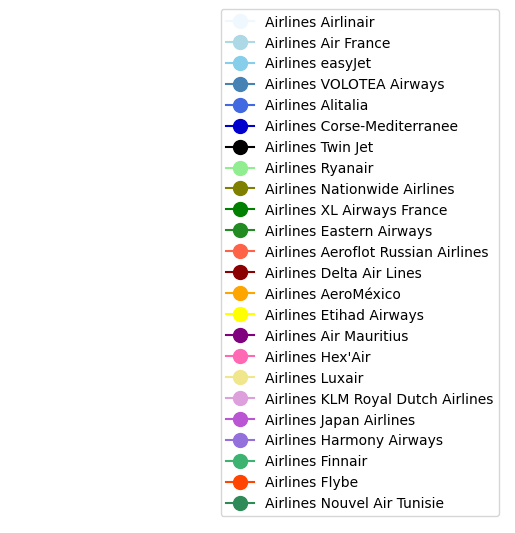

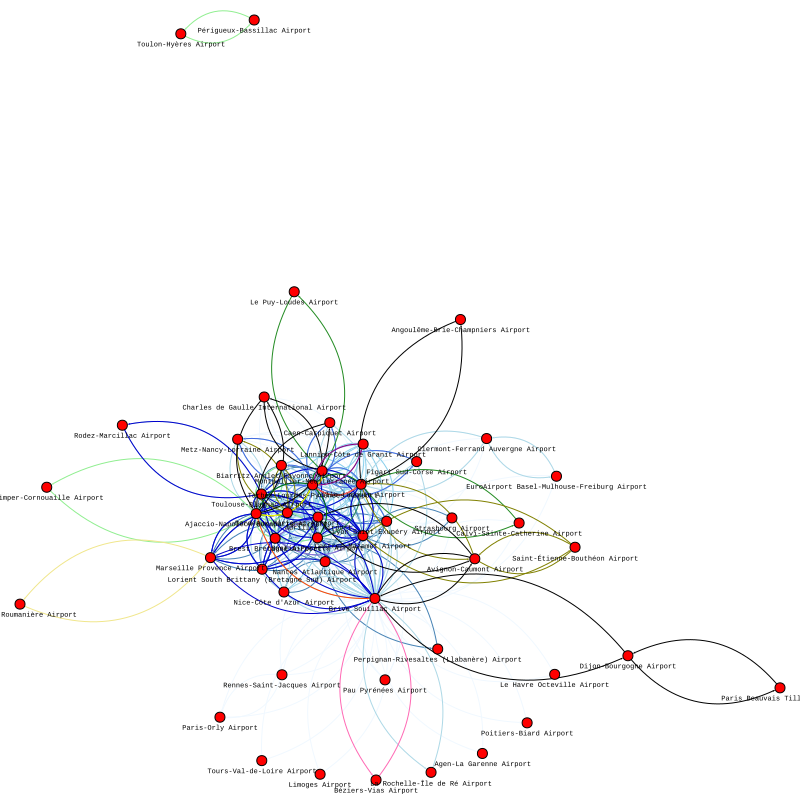

In [58]:
import matplotlib.pyplot as plt

# Definisci una mappatura dei colori per i diversi pesi degli archi
edge_colors = {
    'Airlinair'                   : '#f0f8ff', # Azzurro molto chiaro
    'Air France'                  : '#add8e6', # Azzurro chiaro
    'easyJet'                     : '#87ceeb', # Azzurro moderato
    'VOLOTEA Airways'             : '#4682b4', # Blu acciaio
    'Alitalia'                    : '#4169e1', # Blu reale
    'Corse-Mediterranee'          : '#0000cd', # Blu medio
    'Twin Jet'                    : '#000000', # Nero
    'Ryanair'                     : '#90ee90', # Verde chiaro
    'Nationwide Airlines'         : '#808000', # Verde oliva
    'XL Airways France'           : '#008000', # Verde smeraldo
    'Eastern Airways'             : '#228b22', # Verde bosco
    'Aeroflot Russian Airlines'   : '#ff6347', # Rosso chiaro
    'Delta Air Lines'             : '#8b0000', # Rosso scuro
    'AeroMéxico'                  : '#ffa500', # Arancione
    'Etihad Airways'              : '#ffff00', # Giallo
    'Air Mauritius'               : '#800080', # Viola
    "Hex'Air"                     : '#ff69b4', # Rosa
    'Luxair'                      : '#f0e68c', # Giallo chiaro
    'KLM Royal Dutch Airlines'    : '#dda0dd', # Prugna
    'Japan Airlines'              : '#ba55d3', # Orchidea medio
    'Harmony Airways'             : '#9370db', # Viola medio
    'Finnair'                     : '#3cb371', # Verde mare medio
    'Flybe'                       : '#ff4500', # Arancione rosso
    'Nouvel Air Tunisie'          : '#2e8b57'  # Verde mare
}

color_legend = [
    ('Airlinair', '#f0f8ff'),               # Azzurro molto chiaro
    ('Air France', '#add8e6'),              # Azzurro chiaro
    ('easyJet', '#87ceeb'),                 # Azzurro moderato
    ('VOLOTEA Airways', '#4682b4'),         # Blu acciaio
    ('Alitalia', '#4169e1'),                # Blu reale
    ('Corse-Mediterranee', '#0000cd'),      # Blu medio
    ('Twin Jet', '#000000'),                # Nero
    ('Ryanair', '#90ee90'),                 # Verde chiaro
    ('Nationwide Airlines', '#808000'),     # Verde oliva
    ('XL Airways France', '#008000'),       # Verde smeraldo
    ('Eastern Airways', '#228b22'),         # Verde bosco
    ('Aeroflot Russian Airlines', '#ff6347'), # Rosso chiaro
    ('Delta Air Lines', '#8b0000'),         # Rosso scuro
    ('AeroMéxico', '#ffa500'),              # Arancione
    ('Etihad Airways', '#ffff00'),          # Giallo
    ('Air Mauritius', '#800080'),           # Viola
    ("Hex'Air", '#ff69b4'),                 # Rosa
    ('Luxair', '#f0e68c'),                  # Giallo chiaro
    ('KLM Royal Dutch Airlines', '#dda0dd'),# Prugna
    ('Japan Airlines', '#ba55d3'),          # Orchidea medio
    ('Harmony Airways', '#9370db'),         # Viola medio
    ('Finnair', '#3cb371'),                 # Verde mare medio
    ('Flybe', '#ff4500'),                   # Arancione rosso
    ('Nouvel Air Tunisie', '#2e8b57')       # Verde mare
]

# Creiamo una legenda personalizzata
legend_elements = [plt.Line2D([0], [0], marker='o', color=color, label=f'Airlines {name}', markersize=10)
                   for name, color in color_legend]

# Visualizziamo la legenda senza assi
plt.axis('off')  # Rimuove gli assi
plt.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(1, 0))
plt.show()

# Mostrare il grafico
ig.plot(g_airlines
        , vertex_label=g.vs['name']
        , vertex_label_dist=1.5
        #, layout=g.layout('fruchterman_reingold')
        , bbox=(800, 800)
        , margin=20
        , vertex_size=10
        , edge_arrow_size=0.2
        , edge_curved=True
        #, edge_label=g.es['weight']
        , edge_label_dist= 2
        , vertex_label_size= 7
        , edge_label_size= 5
        , edge_color=[edge_colors[name] for name in g_airlines.es['Airline_name']]
        )


In [59]:
tratte_uniche1 = set()
for edge in g_airlines.es:
    source = g_airlines.vs[edge.source]['name']
    dest = g_airlines.vs[edge.target]['name']
    tratte_uniche1.add((source, dest))

# Stampa tutte le tratte uniche
for tratta in tratte_uniche1:
    print(f"Tratta aerea: {tratta[0]} -> {tratta[1]}")

Tratta aerea: Paris-Orly Airport -> Caen-Carpiquet Airport
Tratta aerea: Bastia-Poretta Airport -> Nice-Côte d'Azur Airport
Tratta aerea: Lille-Lesquin Airport -> Bastia-Poretta Airport
Tratta aerea: Tours-Val-de-Loire Airport -> Marseille Provence Airport
Tratta aerea: Nantes Atlantique Airport -> Bordeaux-Mérignac Airport
Tratta aerea: Nice-Côte d'Azur Airport -> Ajaccio-Napoléon Bonaparte Airport
Tratta aerea: Nice-Côte d'Azur Airport -> Brest Bretagne Airport
Tratta aerea: Charles de Gaulle International Airport -> Ajaccio-Napoléon Bonaparte Airport
Tratta aerea: Figari Sud-Corse Airport -> Paris-Orly Airport
Tratta aerea: Paris-Orly Airport -> La Rochelle-Île de Ré Airport
Tratta aerea: Bordeaux-Mérignac Airport -> Nantes Atlantique Airport
Tratta aerea: Bastia-Poretta Airport -> Paris-Orly Airport
Tratta aerea: Rennes-Saint-Jacques Airport -> Marseille Provence Airport
Tratta aerea: Metz-Nancy-Lorraine Airport -> Lyon Saint-Exupéry Airport
Tratta aerea: Paris-Orly Airport -> Cler

Funzione per simulare attacchi agli archi

In [60]:
def simulate_edge_attack(graph, num_attacks, ordered_attributes=[]):
    initial_giant_component = graph.components().giant()
    initial_giant_component_size = len(initial_giant_component.vs)
    initial_edge_count = graph.ecount()
    initial_diameter = initial_giant_component.diameter()
    initial_avg_path_length = graph.average_path_length()
    initial_efficiency = calculate_global_efficiency(graph)

    metrics = {
        'giant_component_size': [initial_giant_component_size],
        'edge_count': [initial_edge_count],
        'diameter': [initial_diameter],
        'avg_path_length': [initial_avg_path_length],
        'efficiency': [initial_efficiency],
        'edges_removed': [0]
    }

    removed_edges = []
    unique_airlines = list(set(graph.es["Airline_name"]))

    if ordered_attributes:
        for attribute in ordered_attributes:
            if num_attacks <= 0 or len(unique_airlines) == 0:
                break
            if attribute in unique_airlines:
                unique_airlines.remove(attribute)
                edges_to_remove = [e.index for e in graph.es if e["Airline_name"] == attribute]
                removed_edges.append(attribute)
                graph.delete_edges(edges_to_remove)
                num_attacks -= 1

                giant_component = graph.components().giant() if len(graph.components()) > 0 else ig.Graph()
                giant_component_size = len(giant_component.vs)
                edge_count = graph.ecount()
                diameter = giant_component.diameter() if giant_component_size > 1 else 0
                avg_path_length = graph.average_path_length() if len(graph.vs) > 1 else 0
                efficiency = calculate_global_efficiency(graph)

                metrics['giant_component_size'].append(giant_component_size)
                metrics['edge_count'].append(edge_count)
                metrics['diameter'].append(diameter)
                metrics['avg_path_length'].append(avg_path_length)
                metrics['efficiency'].append(efficiency)
                metrics['edges_removed'].append(len(removed_edges))

    else:
        for _ in range(num_attacks):
            if len(unique_airlines) == 0:
                break
            airline_to_remove = random.choice(unique_airlines)
            unique_airlines.remove(airline_to_remove)
            edges_to_remove = [e.index for e in graph.es if e["Airline_name"] == airline_to_remove]
            removed_edges.append(airline_to_remove)
            graph.delete_edges(edges_to_remove)

            giant_component = graph.components().giant() if len(graph.components()) > 0 else ig.Graph()
            giant_component_size = len(giant_component.vs)
            edge_count = graph.ecount()
            diameter = giant_component.diameter() if giant_component_size > 1 else 0
            avg_path_length = graph.average_path_length() if len(graph.vs) > 1 else 0
            efficiency = calculate_global_efficiency(graph)

            metrics['giant_component_size'].append(giant_component_size)
            metrics['edge_count'].append(edge_count)
            metrics['diameter'].append(diameter)
            metrics['avg_path_length'].append(avg_path_length)
            metrics['efficiency'].append(efficiency)
            metrics['edges_removed'].append(len(removed_edges))

    graph.vs["color"] = "white"
    name_values = giant_component.vs["name"]
    for v in graph.vs:
        if v["name"] in name_values:
            v["color"] = "green"

    layout = graph.layout("fr")

    return {
        "graph": graph,
        "removed_edges": removed_edges,
        "metrics": metrics
    }

Attacco Casuale

In [61]:
# Simula un attacco rimuovendo 2 attributi casuali
results = simulate_edge_attack(g_airlines.copy(), 5)
metrics_edge_random = results["metrics"]
print("Attacco casuale:", results)


Attacco casuale: {'graph': <igraph.Graph object at 0x7958c01c4840>, 'removed_edges': ['easyJet', 'Alitalia', 'Finnair', 'Flybe', 'Air France'], 'metrics': {'giant_component_size': [46, 46, 46, 46, 46, 45], 'edge_count': [483, 427, 389, 388, 387, 271], 'diameter': [4, 5, 5, 5, 5, 6], 'avg_path_length': [2.1254826254826256, 2.168918918918919, 2.168918918918919, 2.168918918918919, 2.168918918918919, 2.4470232088799193], 'efficiency': [0.4874408983451548, 0.47934397163120745, 0.47934397163120745, 0.47934397163120745, 0.47934397163120745, 0.4194961583924405], 'edges_removed': [0, 1, 2, 3, 4, 5]}}


<ipython-input-32-3806aaa81a8d>:7: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = graph.shortest_paths()


In [62]:
tratte_uniche = set()
for edge in results["graph"].es:
    source = results["graph"].vs[edge.source]['name']
    dest = results["graph"].vs[edge.target]['name']
    tratte_uniche.add((source, dest))

# Stampa tutte le tratte uniche
for tratta in tratte_uniche:
    print(f"Tratta aerea: {tratta[0]} -> {tratta[1]}")

Tratta aerea: Ajaccio-Napoléon Bonaparte Airport -> Nantes Atlantique Airport
Tratta aerea: Ajaccio-Napoléon Bonaparte Airport -> Bordeaux-Mérignac Airport
Tratta aerea: Charles de Gaulle International Airport -> Lyon Saint-Exupéry Airport
Tratta aerea: Caen-Carpiquet Airport -> Lyon Saint-Exupéry Airport
Tratta aerea: Rodez-Marcillac Airport -> Paris-Orly Airport
Tratta aerea: Paris-Orly Airport -> Caen-Carpiquet Airport
Tratta aerea: Paris Beauvais Tillé Airport -> Béziers-Vias Airport
Tratta aerea: Castres-Mazamet Airport -> Ajaccio-Napoléon Bonaparte Airport
Tratta aerea: Bastia-Poretta Airport -> Nice-Côte d'Azur Airport
Tratta aerea: Ajaccio-Napoléon Bonaparte Airport -> Paris-Orly Airport
Tratta aerea: Lille-Lesquin Airport -> Bastia-Poretta Airport
Tratta aerea: Castres-Mazamet Airport -> Agen-La Garenne Airport
Tratta aerea: Bordeaux-Mérignac Airport -> Nice-Côte d'Azur Airport
Tratta aerea: Nantes Atlantique Airport -> Bordeaux-Mérignac Airport
Tratta aerea: Tours-Val-de-Loir

In [63]:
# Supponiamo di avere i due set già creati: tratte_uniche1 e tratte_uniche

# Differenza tra i due set
differenza_tratte = tratte_uniche1 - tratte_uniche

# Stampa gli elementi presenti in tratte_uniche1 ma non in tratte_uniche
for tratta in differenza_tratte:
    print(f"Tratta unica in tratte_uniche1: {tratta[0]} -> {tratta[1]}")


Tratta unica in tratte_uniche1: Rennes-Saint-Jacques Airport -> Charles de Gaulle International Airport
Tratta unica in tratte_uniche1: Toulouse-Blagnac Airport -> Strasbourg Airport
Tratta unica in tratte_uniche1: Nantes Atlantique Airport -> Paris-Orly Airport
Tratta unica in tratte_uniche1: Charles de Gaulle International Airport -> Ajaccio-Napoléon Bonaparte Airport
Tratta unica in tratte_uniche1: Ajaccio-Napoléon Bonaparte Airport -> Charles de Gaulle International Airport
Tratta unica in tratte_uniche1: Paris-Orly Airport -> Marseille Provence Airport
Tratta unica in tratte_uniche1: Paris-Orly Airport -> Toulouse-Blagnac Airport
Tratta unica in tratte_uniche1: Montpellier-Méditerranée Airport -> EuroAirport Basel-Mulhouse-Freiburg Airport
Tratta unica in tratte_uniche1: Rennes-Saint-Jacques Airport -> Marseille Provence Airport
Tratta unica in tratte_uniche1: Bordeaux-Mérignac Airport -> Paris-Orly Airport
Tratta unica in tratte_uniche1: Paris-Orly Airport -> Clermont-Ferrand Auv

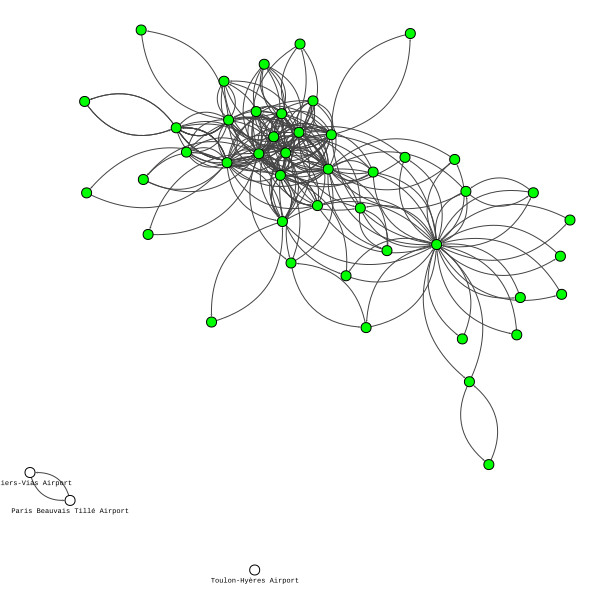

In [64]:
vertex_labels = [
    name if color != 'green' else ''
    for name, color in zip(results["graph"].vs['name'], results["graph"].vs['color'])
]

ig.plot(results["graph"]
        , vertex_label = vertex_labels
        , vertex_label_dist = 1.5
        , bbox=(600, 600)
        , margin=30
        , vertex_size= 10
        , edge_arrow_size=0.2
        , edge_curved=True
        , edge_label_dist= 2
        , vertex_label_size= 7
        , edge_label_size= 5
        ,vertex_color = results["graph"].vs["color"]
        )

Attacco Mirato

In [65]:
# Simula un attacco rimuovendo specifici attributi
results = simulate_edge_attack(g_airlines.copy(), 5, ordered_airlines)
metrics_edge_ordered = results["metrics"]
print("Attacco ordinato:", results)


Attacco ordinato: {'graph': <igraph.Graph object at 0x7958c01c4b40>, 'removed_edges': ['Airlinair', 'Air France', 'easyJet', 'VOLOTEA Airways', 'Alitalia'], 'metrics': {'giant_component_size': [46, 38, 35, 35, 31, 29], 'edge_count': [483, 367, 251, 195, 147, 109], 'diameter': [4, 5, 5, 6, 6, 6], 'avg_path_length': [2.1254826254826256, 2.2926136363636362, 2.337248322147651, 2.547818791946309, 2.609442060085837, 2.699017199017199], 'efficiency': [0.4874408983451548, 0.3199763593380638, 0.267789598108748, 0.24602541371158326, 0.18860815602836778, 0.16083776595744612], 'edges_removed': [0, 1, 2, 3, 4, 5]}}


<ipython-input-32-3806aaa81a8d>:7: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = graph.shortest_paths()


In [66]:
tratte_uniche = set()
for edge in results["graph"].es:
    source = results["graph"].vs[edge.source]['name']
    dest = results["graph"].vs[edge.target]['name']
    tratte_uniche.add((source, dest))

# Stampa tutte le tratte uniche
for tratta in tratte_uniche:
    print(f"Tratta aerea: {tratta[0]} -> {tratta[1]}")

Tratta aerea: Ajaccio-Napoléon Bonaparte Airport -> Nantes Atlantique Airport
Tratta aerea: Charles de Gaulle International Airport -> Lyon Saint-Exupéry Airport
Tratta aerea: Paris Beauvais Tillé Airport -> Béziers-Vias Airport
Tratta aerea: Bastia-Poretta Airport -> Nice-Côte d'Azur Airport
Tratta aerea: Ajaccio-Napoléon Bonaparte Airport -> Paris-Orly Airport
Tratta aerea: Tours-Val-de-Loire Airport -> Marseille Provence Airport
Tratta aerea: Bordeaux-Mérignac Airport -> Rennes-Saint-Jacques Airport
Tratta aerea: Nice-Côte d'Azur Airport -> Ajaccio-Napoléon Bonaparte Airport
Tratta aerea: Toulouse-Blagnac Airport -> Dijon-Bourgogne Airport
Tratta aerea: Marseille Provence Airport -> Brest Bretagne Airport
Tratta aerea: Figari Sud-Corse Airport -> Paris-Orly Airport
Tratta aerea: Nantes Atlantique Airport -> Bastia-Poretta Airport
Tratta aerea: Bastia-Poretta Airport -> Nantes Atlantique Airport
Tratta aerea: Lyon Saint-Exupéry Airport -> Limoges Airport
Tratta aerea: Nantes Atlantiq

In [67]:
# Supponiamo di avere i due set già creati: tratte_uniche1 e tratte_uniche

# Differenza tra i due set
differenza_tratte = tratte_uniche1 - tratte_uniche

# Stampa gli elementi presenti in tratte_uniche1 ma non in tratte_uniche
for tratta in differenza_tratte:
    print(f"Tratta unica in tratte_uniche1: {tratta[0]} -> {tratta[1]}")


Tratta unica in tratte_uniche1: Ajaccio-Napoléon Bonaparte Airport -> Bordeaux-Mérignac Airport
Tratta unica in tratte_uniche1: Rodez-Marcillac Airport -> Paris-Orly Airport
Tratta unica in tratte_uniche1: Paris-Orly Airport -> Caen-Carpiquet Airport
Tratta unica in tratte_uniche1: Caen-Carpiquet Airport -> Lyon Saint-Exupéry Airport
Tratta unica in tratte_uniche1: Rennes-Saint-Jacques Airport -> Charles de Gaulle International Airport
Tratta unica in tratte_uniche1: Toulouse-Blagnac Airport -> Strasbourg Airport
Tratta unica in tratte_uniche1: Castres-Mazamet Airport -> Ajaccio-Napoléon Bonaparte Airport
Tratta unica in tratte_uniche1: Lille-Lesquin Airport -> Bastia-Poretta Airport
Tratta unica in tratte_uniche1: Castres-Mazamet Airport -> Agen-La Garenne Airport
Tratta unica in tratte_uniche1: Nantes Atlantique Airport -> Bordeaux-Mérignac Airport
Tratta unica in tratte_uniche1: Bordeaux-Mérignac Airport -> Nice-Côte d'Azur Airport
Tratta unica in tratte_uniche1: Brive Souillac Airp

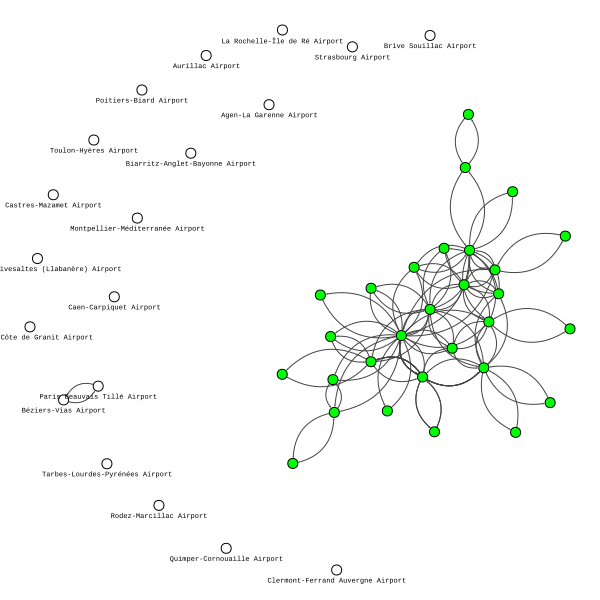

In [68]:
vertex_labels = [
    name if color != 'green' else ''
    for name, color in zip(results["graph"].vs['name'], results["graph"].vs['color'])
]

ig.plot(results["graph"]
        , vertex_label = vertex_labels
        , vertex_label_dist = 1.5
        , bbox=(600, 600)
        , margin=30
        , vertex_size= 10
        , edge_arrow_size=0.2
        , edge_curved=True
        , edge_label_dist= 2
        , vertex_label_size= 7
        , edge_label_size= 5
        ,vertex_color = results["graph"].vs["color"]
        )

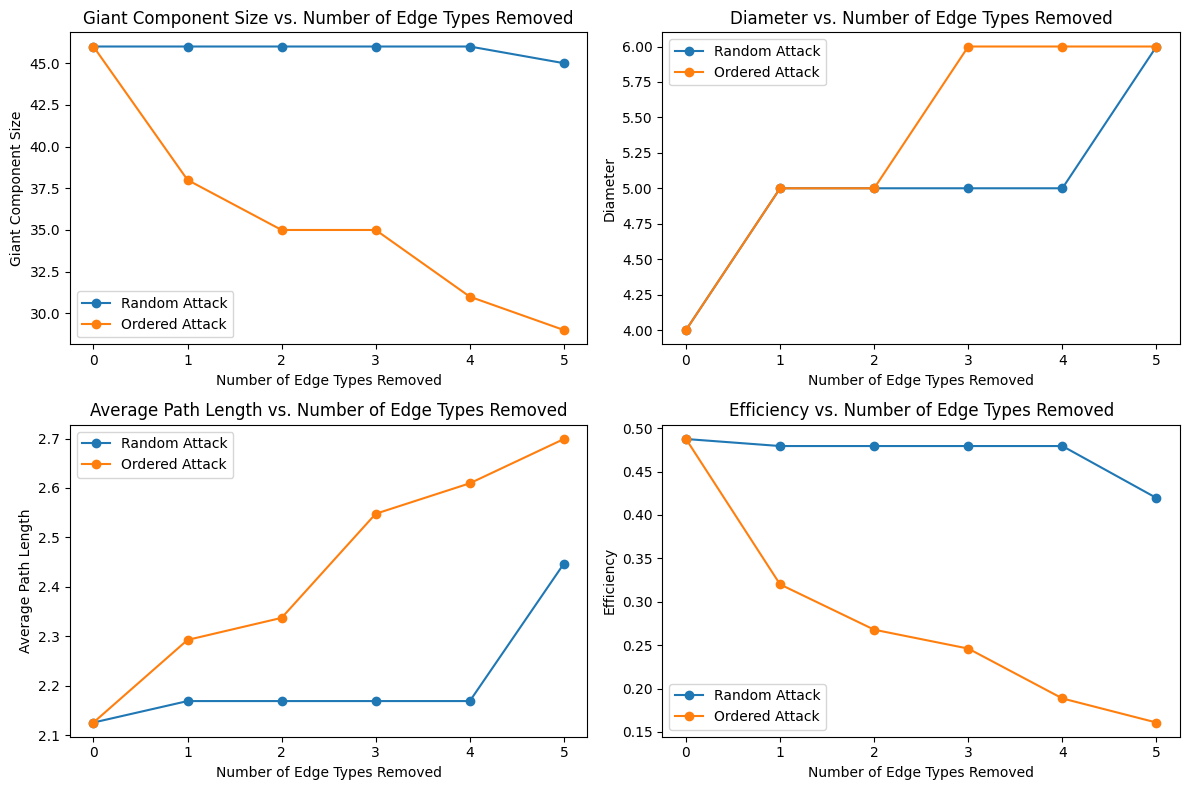

In [69]:
# Creazione dei grafici combinati
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(metrics_edge_random['edges_removed'], metrics_edge_random['giant_component_size'], marker='o', label='Random Attack')
plt.plot(metrics_edge_ordered['edges_removed'], metrics_edge_ordered['giant_component_size'], marker='o', label='Ordered Attack')
plt.xlabel('Number of Edge Types Removed')
plt.ylabel('Giant Component Size')
plt.title('Giant Component Size vs. Number of Edge Types Removed')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(metrics_edge_random['edges_removed'], metrics_edge_random['diameter'], marker='o', label='Random Attack')
plt.plot(metrics_edge_ordered['edges_removed'], metrics_edge_ordered['diameter'], marker='o', label='Ordered Attack')
plt.xlabel('Number of Edge Types Removed')
plt.ylabel('Diameter')
plt.title('Diameter vs. Number of Edge Types Removed')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(metrics_edge_random['edges_removed'], metrics_edge_random['avg_path_length'], marker='o', label='Random Attack')
plt.plot(metrics_edge_ordered['edges_removed'], metrics_edge_ordered['avg_path_length'], marker='o', label='Ordered Attack')
plt.xlabel('Number of Edge Types Removed')
plt.ylabel('Average Path Length')
plt.title('Average Path Length vs. Number of Edge Types Removed')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(metrics_edge_random['edges_removed'], metrics_edge_random['efficiency'], marker='o', label='Random Attack')
plt.plot(metrics_edge_ordered['edges_removed'], metrics_edge_ordered['efficiency'], marker='o', label='Ordered Attack')
plt.xlabel('Number of Edge Types Removed')
plt.ylabel('Efficiency')
plt.title('Efficiency vs. Number of Edge Types Removed')
plt.legend()

plt.tight_layout()
plt.show()